# Torridon Group ca. 975 Ma paleomagnetic pole

## Geologic context

The Torridon Group is the youngest and thickest of the groups of the "Torridonian" succession of NW Scotland - a Neoproterozoic continental red-bed sequence of dominantly fluvial sandstones (Diabaig, Applecross, and Aultbea formations) deposited unconformably above the older Stoer and Sleat groups and beneath the Cambrian unconformity. These rocks were part of Laurentia.

## Paleomagnetic data

The pole is the Lulea Working Group (2009) sample-weighted grand mean of seven Torridon Group paleomagnetic studies - Irving & Runcorn (1957), Stewart & Irving (1974), Smith et al. (1983), Torsvik & Sturt (1987), Potts (1990), Williams & Schmidt (1997), and Borradaile & Geneviciene (2008) - as carried in the Evans et al. (2021) Laurentia compilation. The tilt-corrected mean direction is Dec 119.6 deg / Inc 56.7 deg, giving a pole at **-17.7 deg N / 220.9 deg E (A95 = 7.1 deg)** from N = 880 samples, with mixed (normal + reverse) polarity.

## Age

The Torridon Group is not directly dated, but several lines of evidence constrain deposition to the earliest Neoproterozoic. Deposition postdated the youngest detrital zircons, which range from ca. 1070 to 1000 Ma: the youngest zircon dates from the Applecross Formation are 1071 ± 55 Ma and 1060 ± 18 Ma, whereas those from the stratigraphically higher Aultbea Formation are 992 ± 52 Ma and 1046 ± 26 Ma (Rainbird et al., 2001; Krabbendam et al., 2017). The Torridon Group can be interpreted to predate 717 Ma as it lacks evidence for Cryogenian glaciation. Taken alone, these constraints permit a broad interval of possible ages. However, interpretations of the Torridon Group as a non-marine succession deposited in a Grenvillian foreland-basin setting suggest that deposition may have occurred closer to ca. 1000–950 Ma than to the younger part of the permissible age range (Krabbendam et al., 2017, 2022). Deposition prior to ca. 950 Ma is further supported by the correlative Morar Group having experienced high-grade metamorphism at ca. 950–940 Ma associated with the Renlandian orogeny (Bird et al., 2018; Krabbendam et al., 2022). This interpretation is also consistent with whole-rock Rb–Sr ages of 994 ± 48 Ma and 977 ± 39 Ma from Torridon Group mudstones that have been interpreted to record diagenesis shortly after deposition (Turnbull et al., 1996).

The pole is accordingly assigned **ca. 975 Ma (950–1050 Ma)**, within the ca. 1000–950 Ma interval preferred by Krabbendam et al. (2017, 2022). There is an intriguing similarity between this pole and the ca. 990 Ma Jacobsville pole when Scotland is rotated into Laurentia coordinates (see the APWP comparison below). The similarity between the Torridon and Jacobsville poles may indicate that the two successions are broadly coeval, with both constraining the paleogeographic position of Laurentia in the earliest Neoproterozoic Era. Further improvements to the chronostratigraphy for the Torridon Group could refine this correlation and strengthen our understanding of the position of Rodinia at that time.

## Reference frame

These rocks belong to the **Laurentia-Scotland** terrane: restoring the pole into the Laurentia reference frame requires an Euler rotation. The **Nordic summary below is exported in the unrotated, present-day Scottish coordinates** (applying the rotation to the compilation is left to downstream paleogeographic workflows). For assessment, the pole is shown below in **both** its unrotated and its rotated position, using the Scotland-to-Laurentia rotation of Torsvik & Cocks (2017) as tabulated by Swanson-Hysell (2021, Table 4.1): Euler pole 78.6°N / 161.9°E, rotation angle −31.0°.

## References

Paleomagnetic pole: Lulea Working Group mean (2009), as compiled in Evans et al. (2021).

Age constraints:
- Rainbird, R. H., Hamilton, M. A., & Young, G. M. (2001). Detrital zircon geochronology and provenance of the Torridonian, NW Scotland. Journal of the Geological Society, 158(1), 15–27. https://doi.org/10.1144/jgs.158.1.15
- Turnbull, M. J. M., Whitehouse, M. J., & Moorbath, S. (1996). New isotopic age determinations for the Torridonian, NW Scotland. Journal of the Geological Society, 153(6), 955–964. https://doi.org/10.1144/gsjgs.153.6.0955
- Krabbendam, M., Bonsor, H., Horstwood, M. S. A., & Rivers, T. (2017). Tracking the evolution of the Grenvillian Foreland Basin: constraints from sedimentology and detrital zircon and rutile in the Sleat and Torridon groups, Scotland. Precambrian Research, 295, 67–89. https://doi.org/10.1016/j.precamres.2017.04.027
- Bird, A., Cutts, K., Strachan, R., Thirlwall, M. F., & Hand, M. (2018). First evidence of Renlandian (c. 950–940 Ma) orogeny in mainland Scotland: Implications for the status of the Moine Supergroup and circum-North Atlantic correlations. Precambrian Research, 305, 283–294. https://doi.org/10.1016/j.precamres.2017.12.019
- Krabbendam, M., Strachan, R. A., & Prave, A. (2022). A new stratigraphic framework for the early Neoproterozoic successions of Scotland. Journal of the Geological Society, 179(2), jgs2021-054. https://doi.org/10.1144/jgs2021-054

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the Evans et al. (2021) Laurentia compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed: this is the Lulea Working Group (2009) sample-weighted grand mean of the constituent studies, carried forward into the Nordic compilation format. The pole is reported in its published (unrotated, present-day Scottish) coordinates.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'MEAN Torridon Group'].iloc[0]

# published (unrotated, Scotland-frame) pole and mean direction
pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': ''}     # grand mean: site count (B) left blank
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('MEAN Torridon Group pole (Evans et al., 2021 compilation; unrotated Scotland frame):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  N {int(float(row['N']))} samples")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (polarity: {row['%REV']})")

MEAN Torridon Group pole (Evans et al., 2021 compilation; unrotated Scotland frame):
  PLAT -17.7  PLON 220.9  A95 7.1  N 880 samples
  mean direction Dec 119.6  Inc 56.7  (polarity: MIXED)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
Laurentia_poles = pt.get_Laurentia_poles()
pt.R2_test('Torridon Group', Laurentia_poles)

N = 880 (N ≥ 25; sufficient sample number);
B = n/a (published grand mean of unit means; site number not reported);
K = 1000 (K ≥ 70; concern about underrepresenting PSV);


## Euler rotation into the Laurentia reference frame

The Scotland-to-Laurentia rotation of Torsvik & Cocks (2017) (Swanson-Hysell, 2021, Table 4.1) is applied with `pmag.pt_rot`: Euler pole 78.6 deg N / 161.9 deg E, angle -31.0 deg. This reproduces the rotated pole position carried in the project pole database.

In [4]:
euler_scotland = [78.6, 161.9, -31.0]   # [lat, lon, angle]; Torsvik & Cocks (2017)
rlat, rlon = pmag.pt_rot(euler_scotland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Scottish frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:       {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Scottish frame): -17.7 N / 220.9 E
rotated into the Laurentia frame:       -21.8 N / 188.9 E


## Position within the Laurentia apparent polar wander path

The pole is shown in **separate** plots in its unrotated position (present-day Scottish coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path).

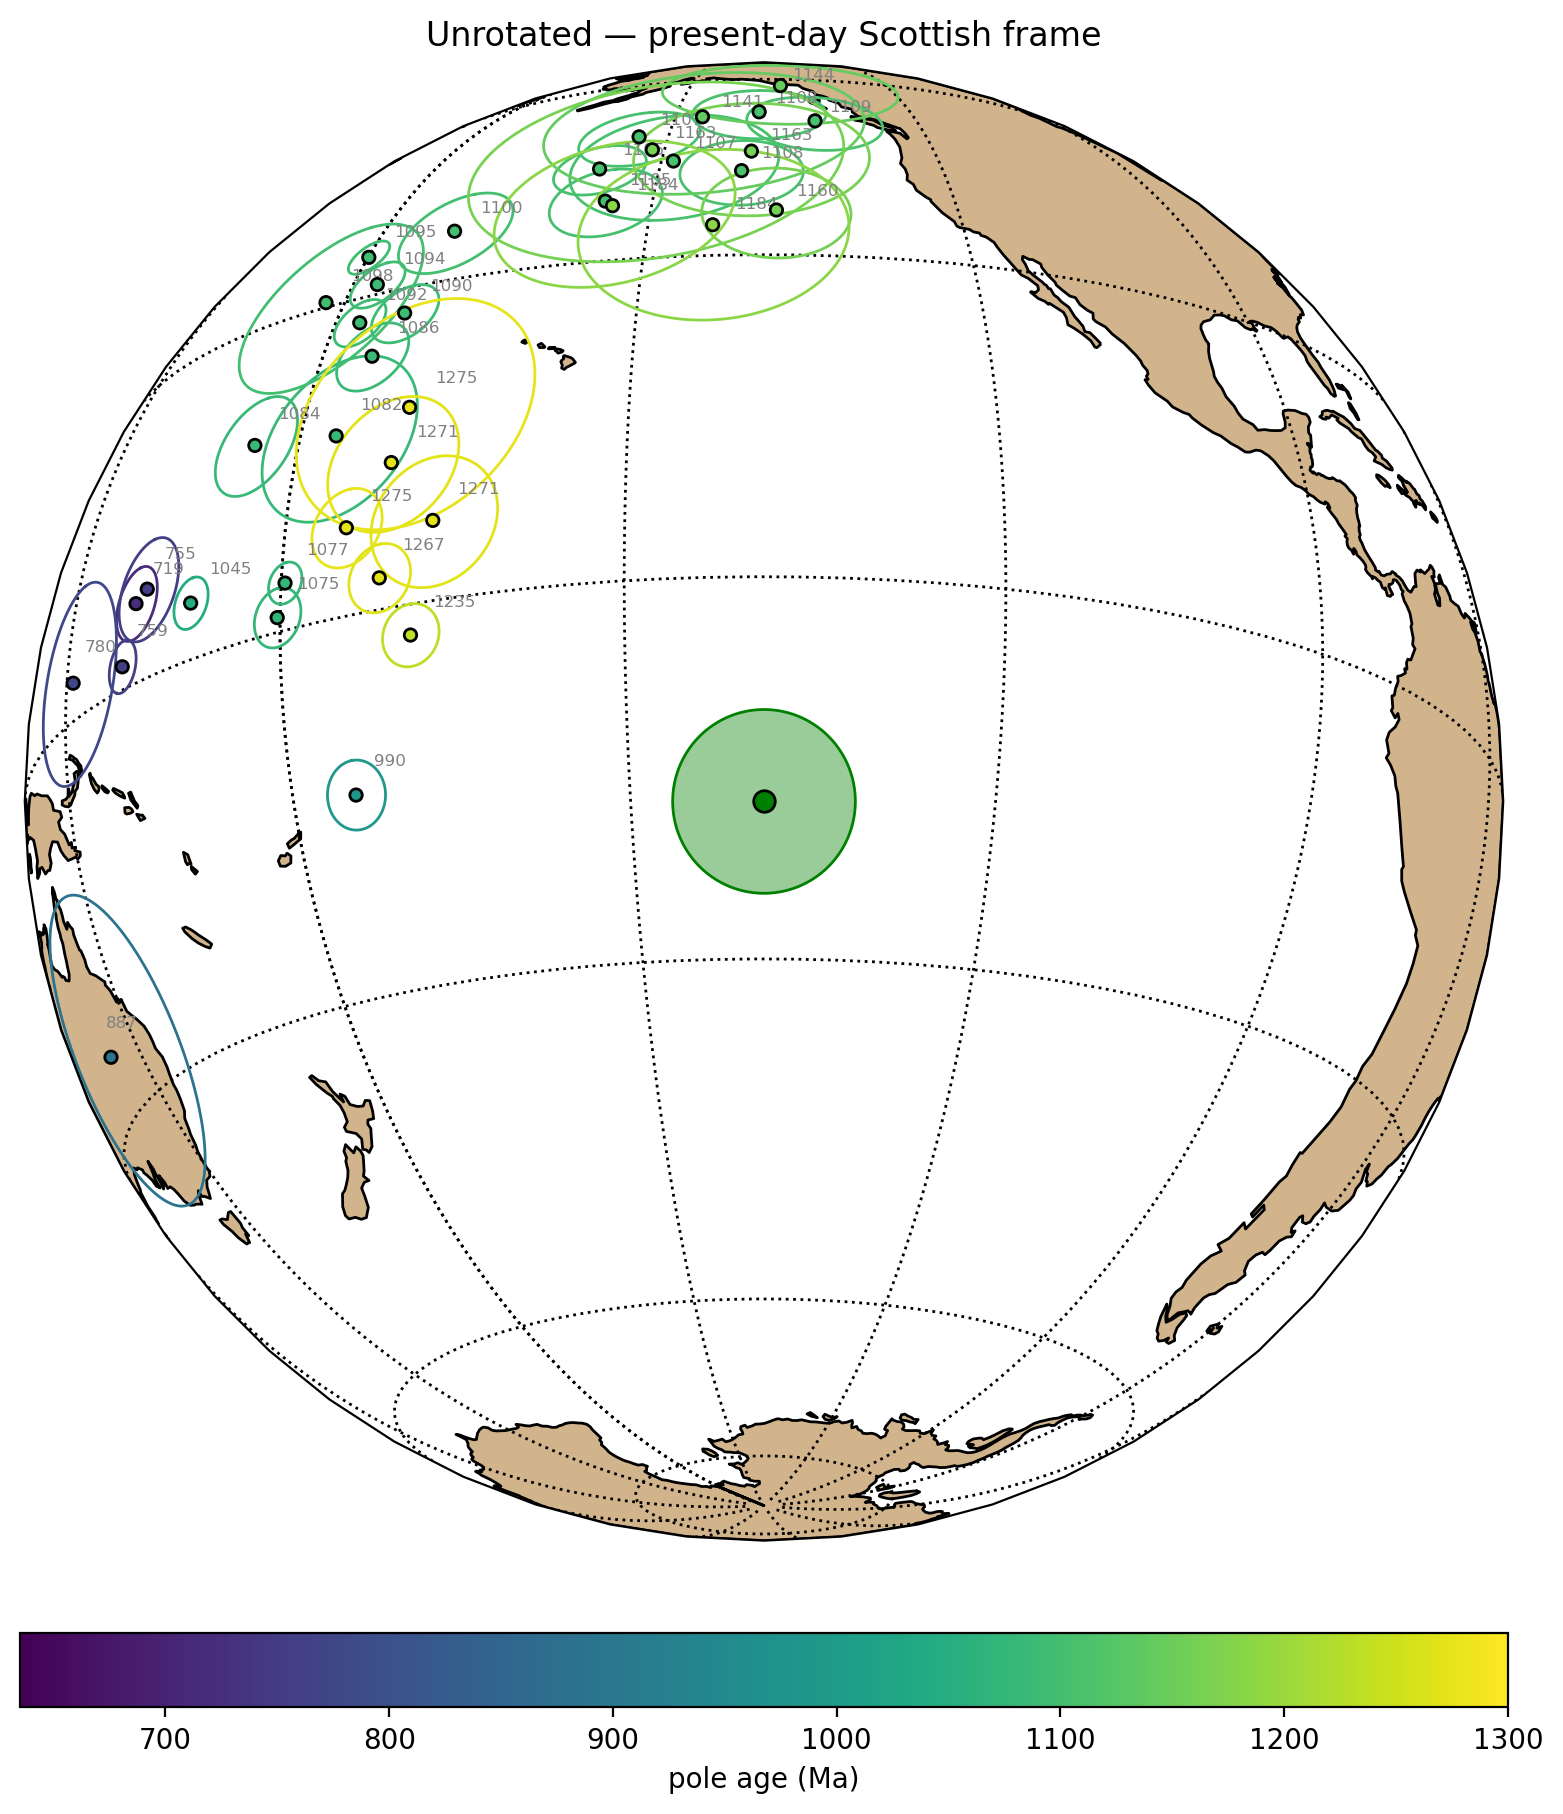

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated — present-day Scottish frame')
plt.show()

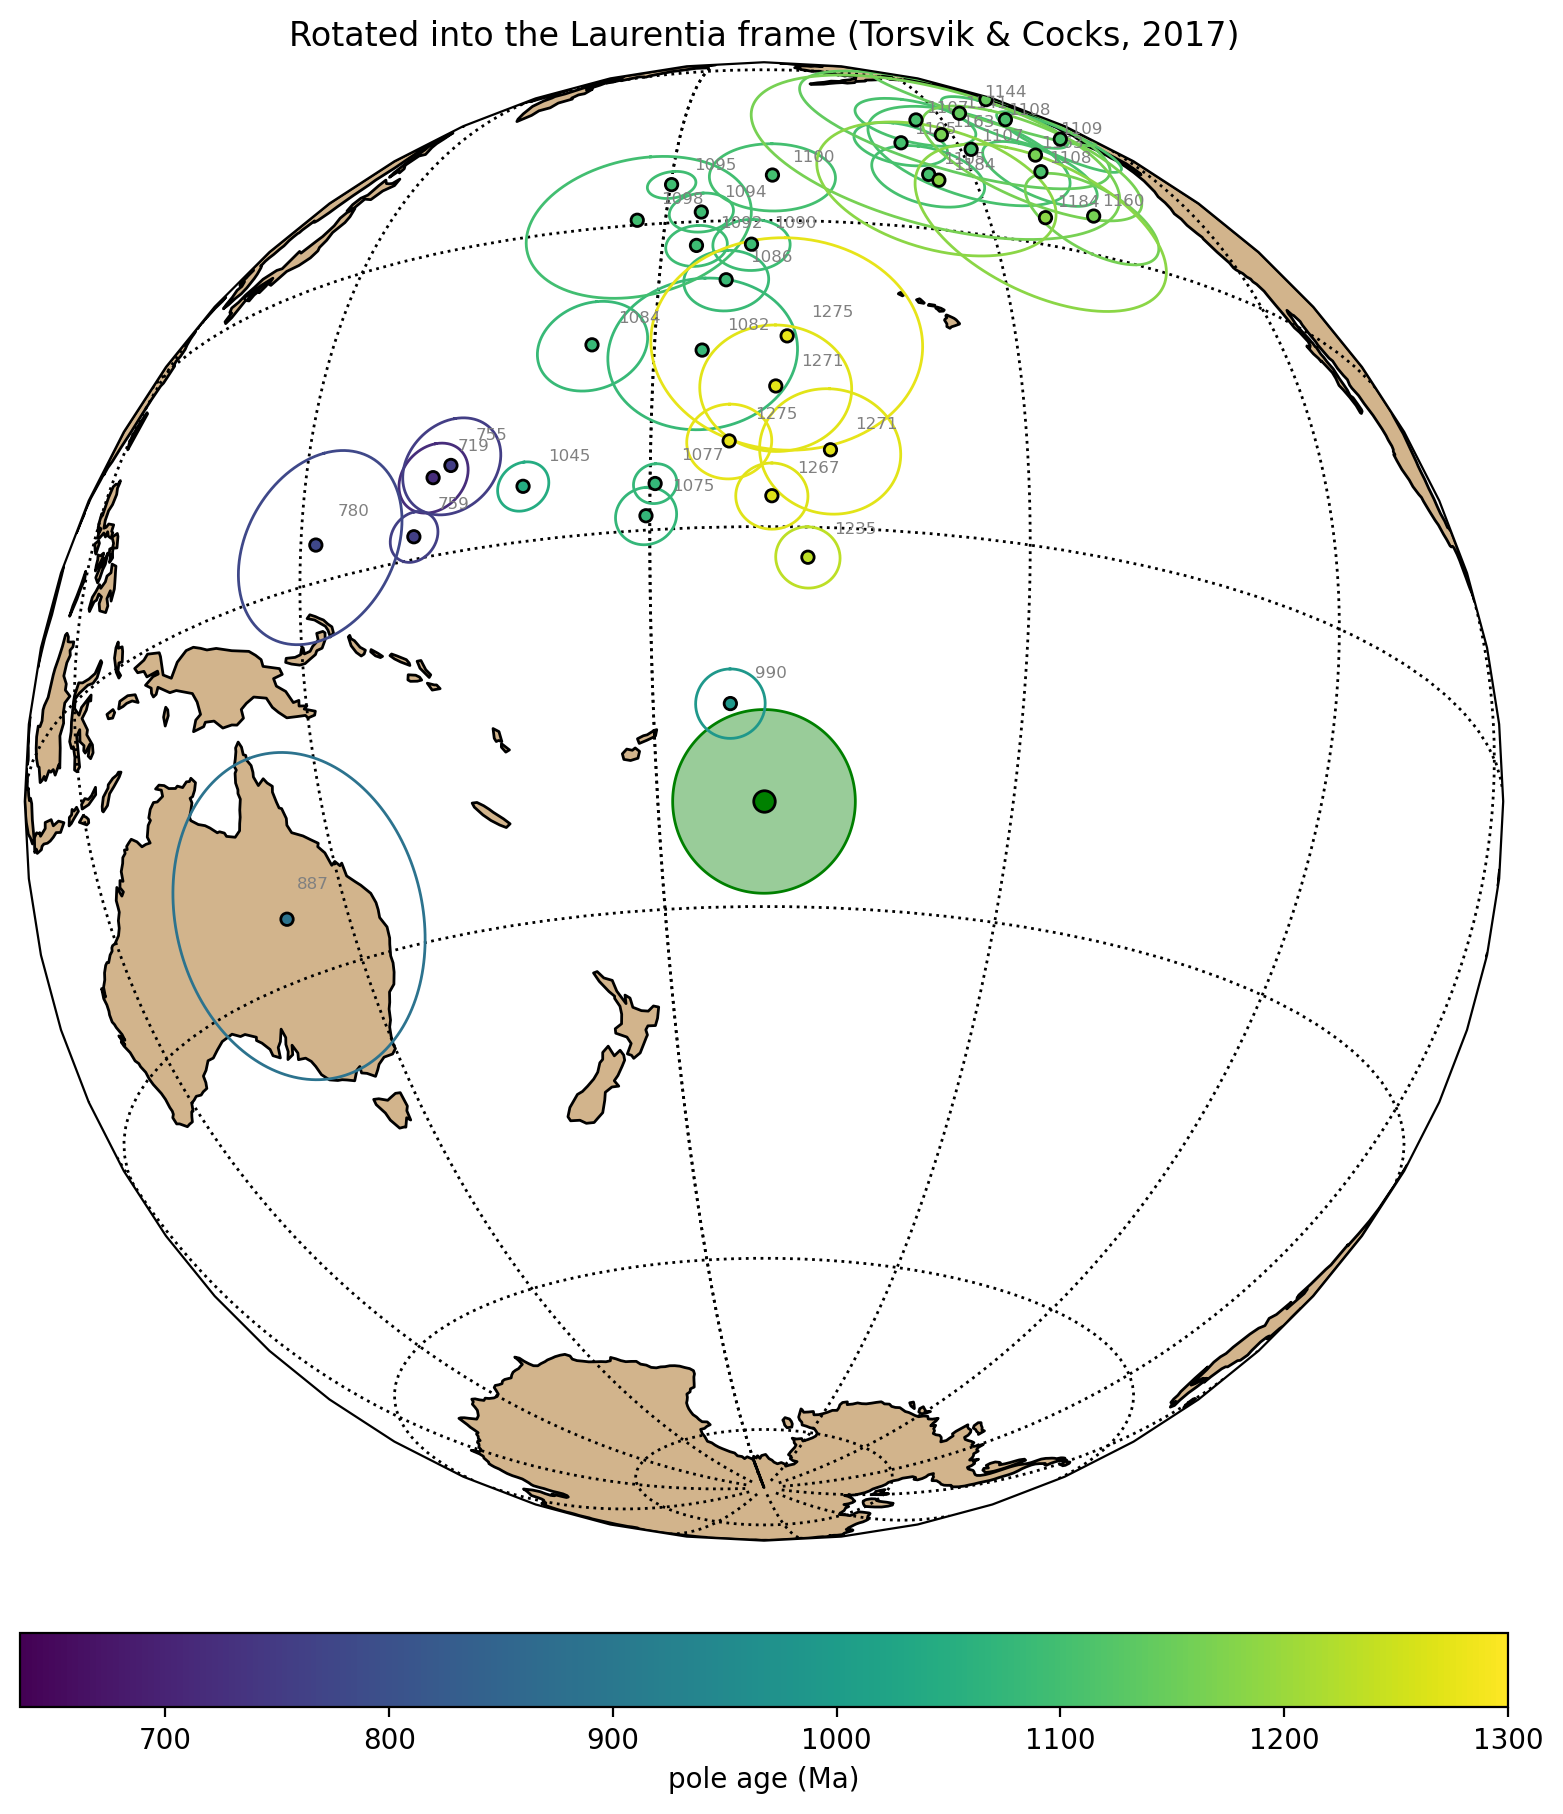

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Torsvik & Cocks, 2017)')
plt.show()

## Comparison with younger Laurentia poles

The same `plot_pole_overlap` comparison is shown for both positions.

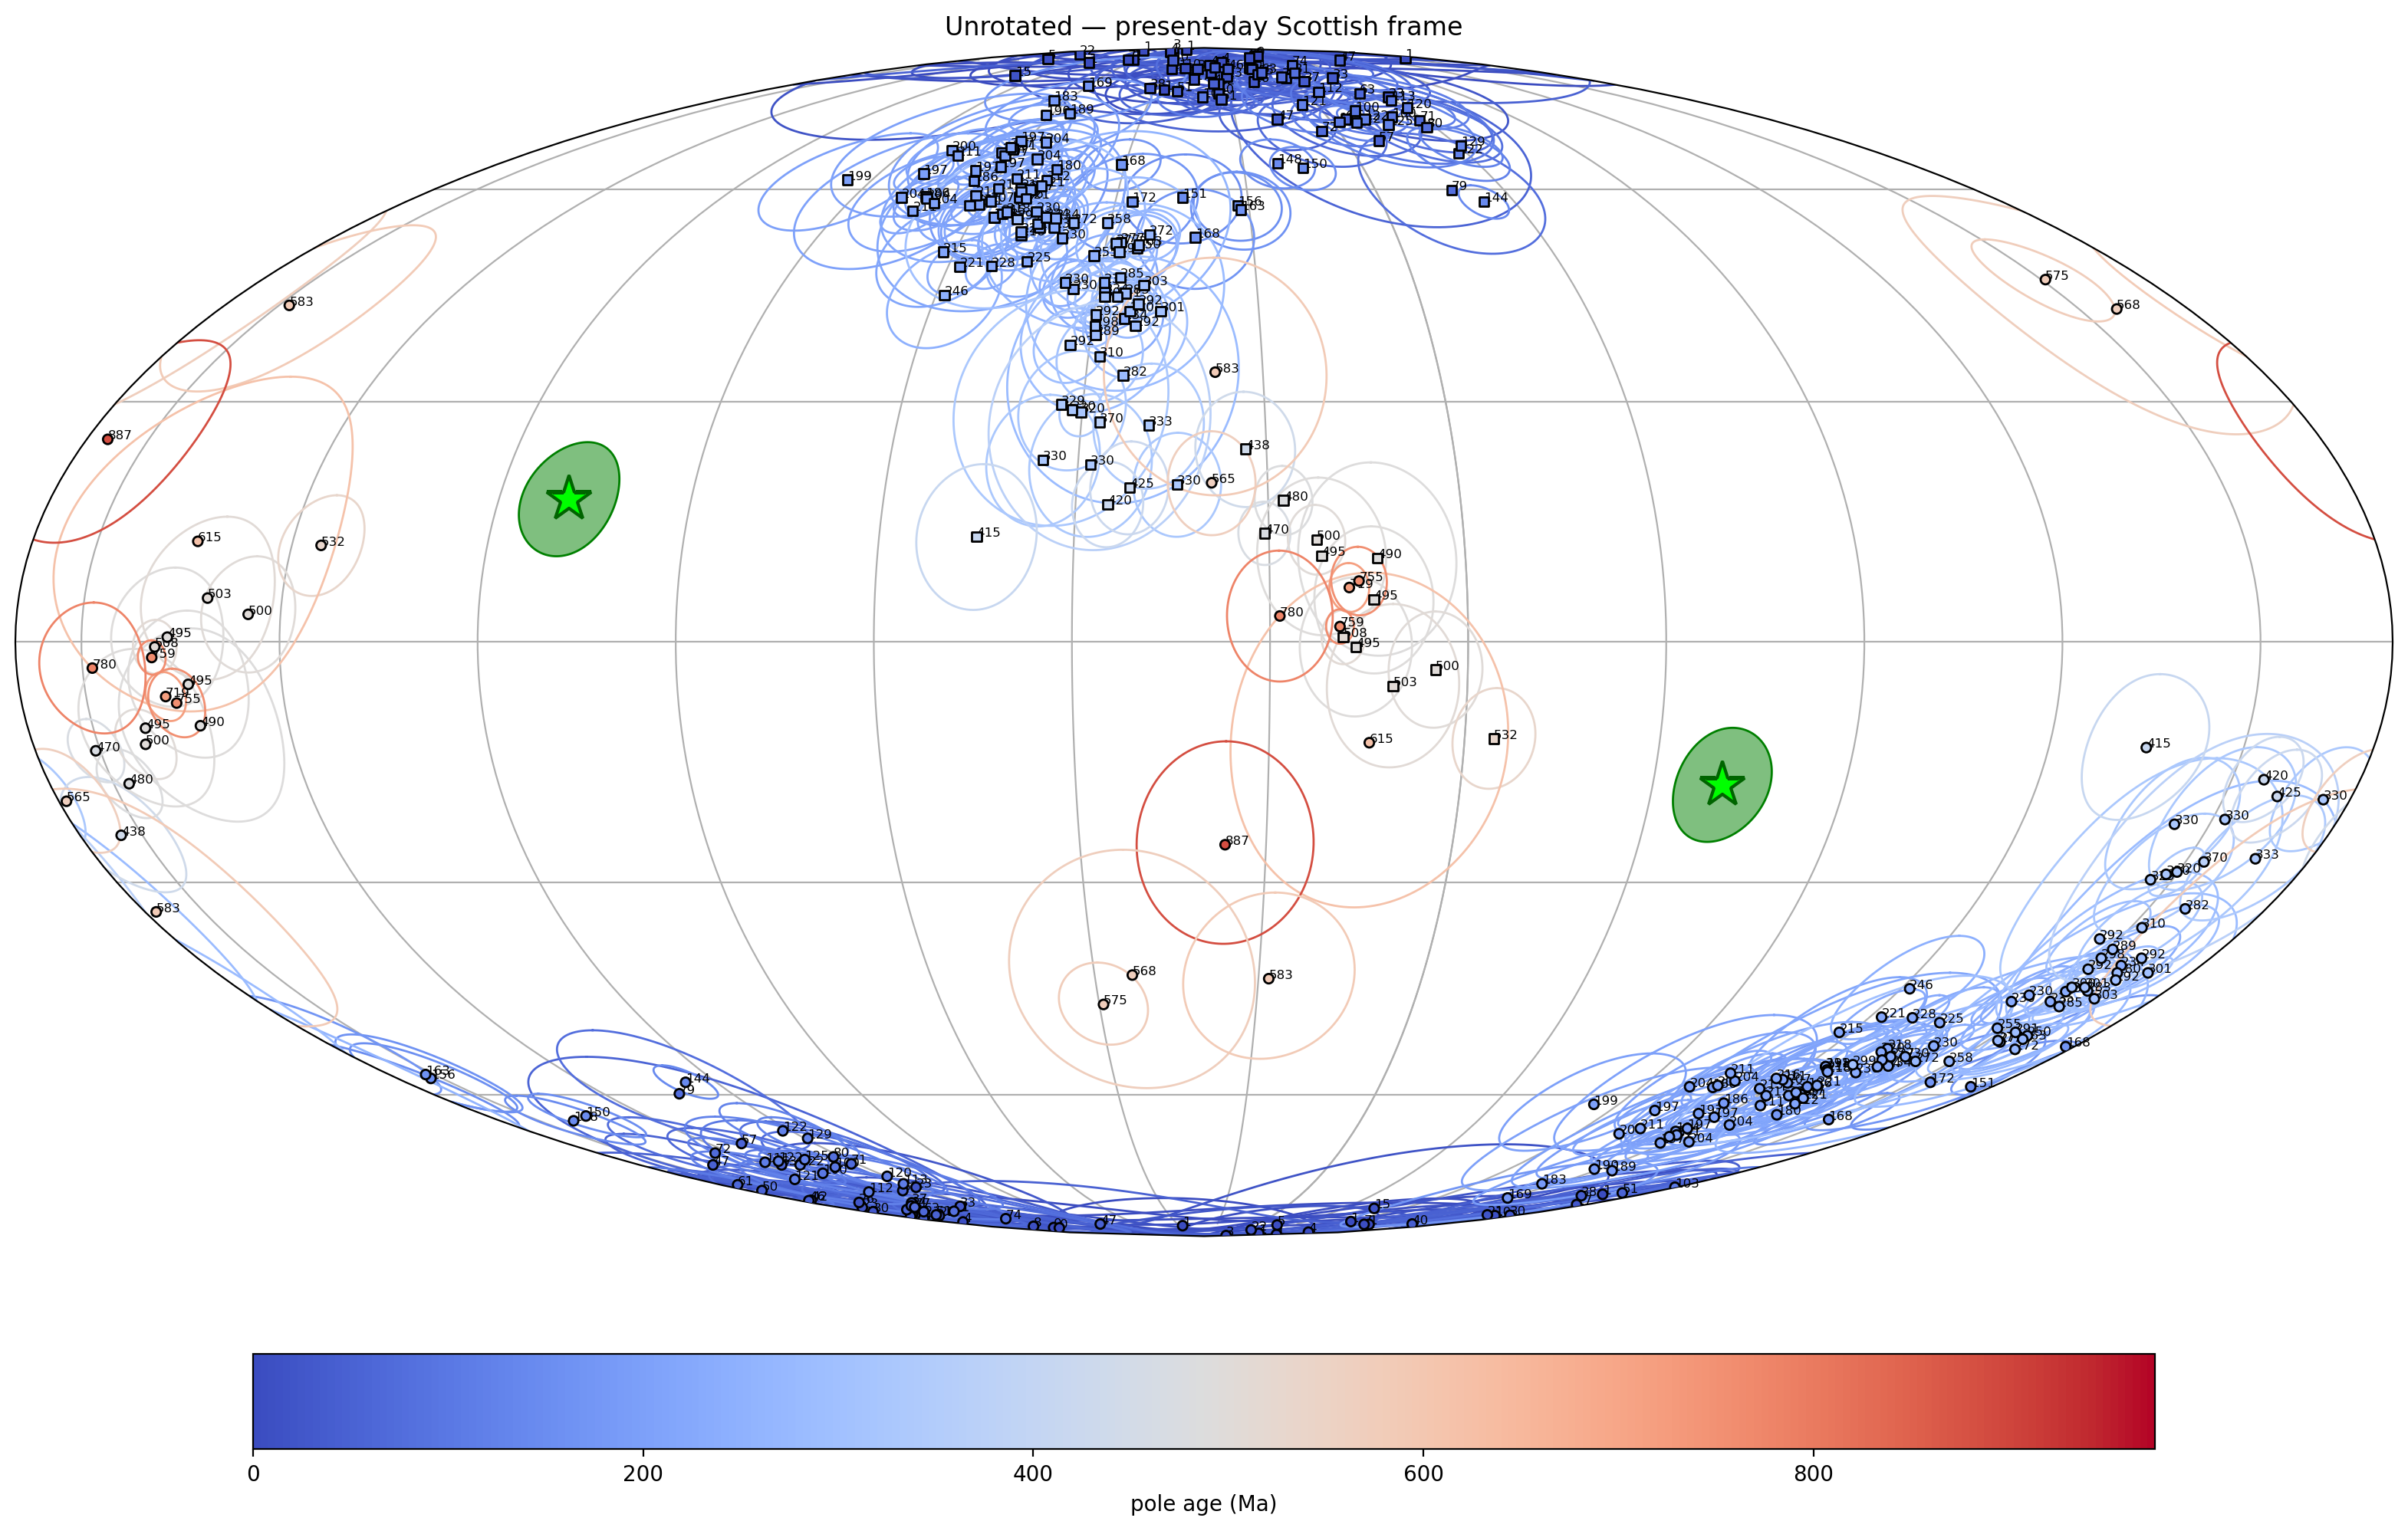

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Torridon Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=975, show=False)
plt.title('Unrotated — present-day Scottish frame')
plt.show()

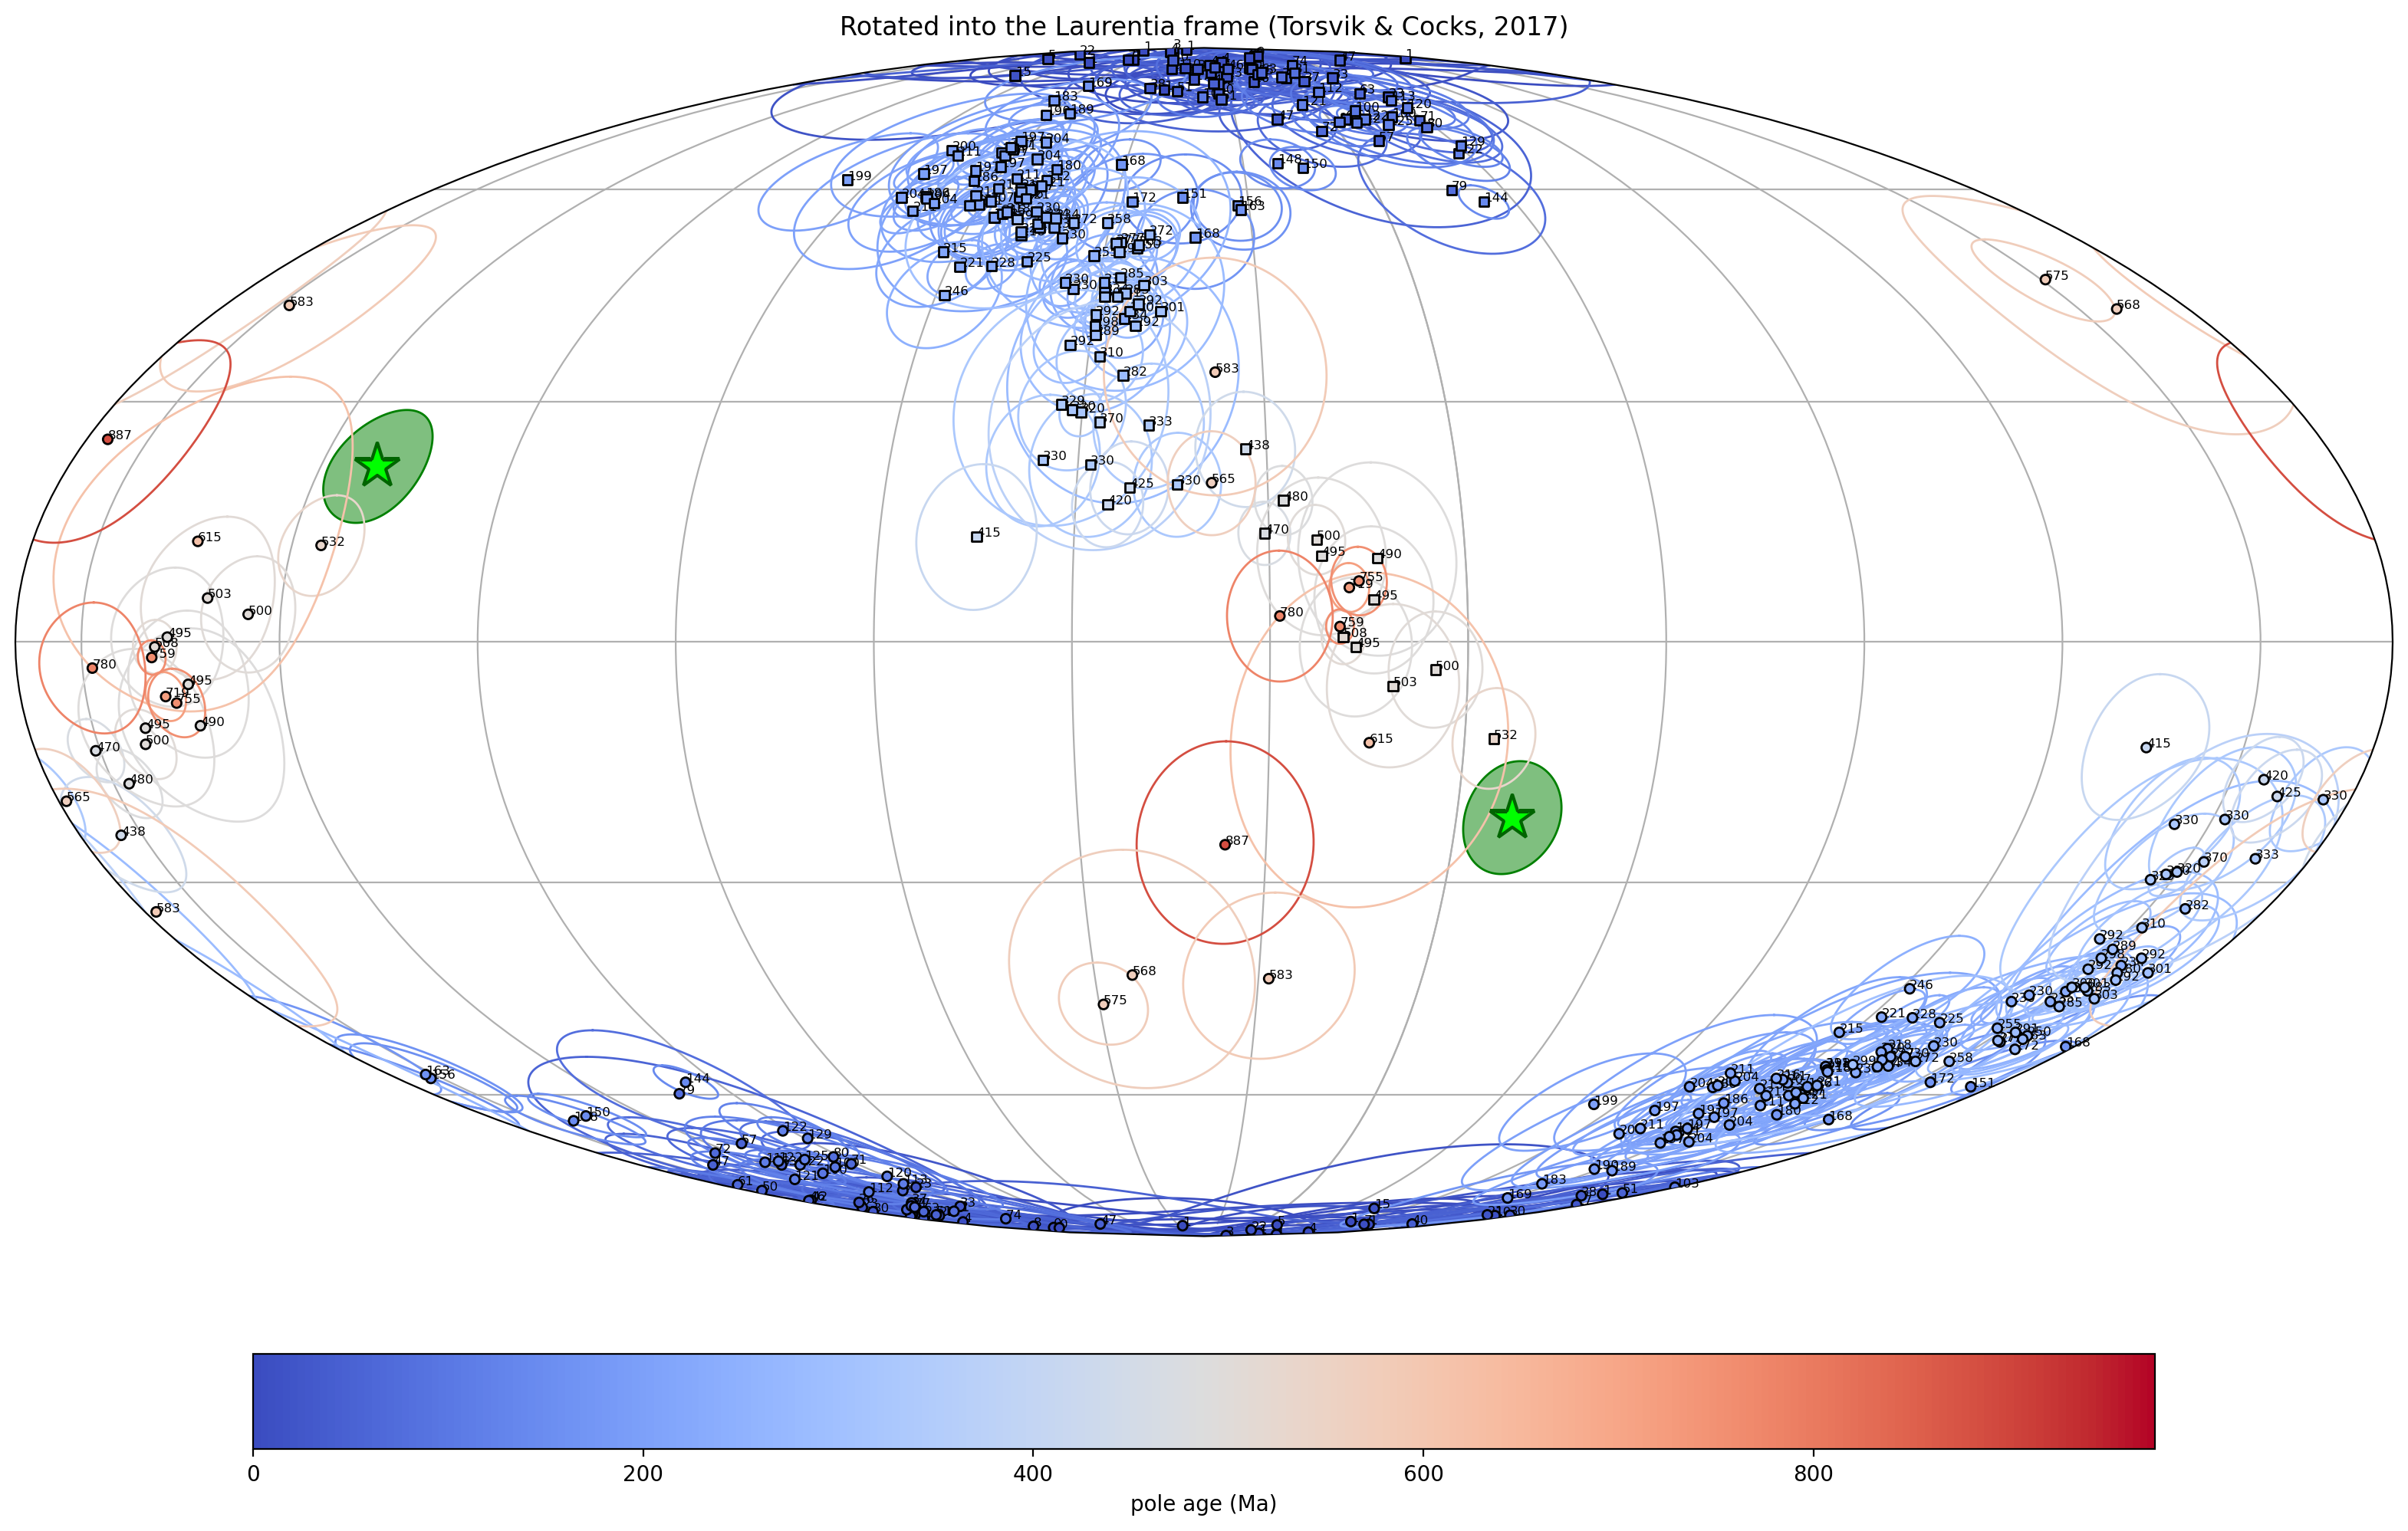

In [8]:
pt.plot_pole_overlap('Torridon Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=975, show=False)
plt.title('Rotated into the Laurentia frame (Torsvik & Cocks, 2017)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format **without Euler rotation** (published Scottish coordinates). Because this is a published grand mean of unit means rather than a recomputed site-level pole, the site count (B) is left blank and the direction precision (KD = 1000, ED95 = 0.1) are the placeholder/sentinel values carried in the source compilation; the meaningful quantities are the pole position and A95.

In [9]:
# grand mean of unit means: one placeholder 'sites' row carrying the sample count + tilt state
row_sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                           'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia-Scotland',
    rockname='Torridon Group',
    sites=row_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='',
    tests='many',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',          # source lists '%REV = MIXED' (dual polarity); see comment
    demag_code=int(float(row['DEMAGCODE'])),
    R1=0, R2=1, R3=1, R4='f',
    R5=0, R6=0, R7=1, Grade='B', Grade_E21='B',
    nominal_age=975,
    lomagage=950, himagage=1050,
    REF_method="The Torridon Group is poorly dated directly. Its youngest detrital zircons range from ca. 1070 to 1000 Ma (Applecross Formation: 1071 ± 55 Ma and 1060 ± 18 Ma; Aultbea Formation: 992 ± 52 Ma and 1046 ± 26 Ma; Rainbird et al., 2001; Krabbendam et al., 2017), and the absence of Cryogenian glacial deposits indicates deposition before ca. 717 Ma. A Grenvillian foreland-basin setting, correlation with the Morar Group metamorphosed at ca. 950-940 Ma during the Renlandian orogeny (Bird et al., 2018; Krabbendam et al., 2022), and whole-rock Rb-Sr ages of 994 ± 48 Ma and 977 ± 39 Ma interpreted as early diagenesis (Turnbull et al., 1996) favor deposition at ca. 1000-950 Ma. The pole is assigned **ca. 975 Ma (950-1050 Ma)**; in Laurentia coordinates it is quite similar to the ca. 990 Ma Jacobsville pole.",
    POLE_AUTHORS='Lulea Working Group mean (Evans et al., 2021 compilation)',
    YEAR=2009,
    JOURNAL='',
    VOLUME='',
    VPAGES='',
    TITLE='MEAN Torridon Group (Lulea Working Group grand mean)',
    COMMENT='Sample-weighted grand mean of seven Torridon Group studies (Irving & Runcorn 1957; Stewart & Irving 1974; Smith et al. 1983; Torsvik & Sturt 1987; Potts 1990; Williams & Schmidt 1997; Borradaile & Geneviciene 2008); mixed polarity pole taken from the Evans et al. (2021) Laurentia compilation..'
)
pt.save_nordic_summary(summary, '975_Torridon')
summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia-Scotland,Torridon Group,,,,many,100,57.9,354.3,,...,The Torridon Group is poorly dated directly. I...,Torridon Group,"Lulea Working Group mean (Evans et al., 2021 c...",2009,,,,MEAN Torridon Group (Lulea Working Group grand...,Sample-weighted grand mean of seven Torridon G...,


## Inclination-shallowing-corrected pole

The pole above is reported as measured. Detrital remanence in sedimentary rocks
is shallowed during compaction, so its inclination — and the paleolatitude that
inclination implies — is a minimum. This pole is a sample-weighted grand mean of seven published studies rather than a single directional data set; the underlying distribution of directions is not available, so the flattening factor cannot be determined by elongation/inclination (E/I) or SVEI.

Following Pierce et al. (2022), the flattening factor is instead resampled from
their compilation of measured *f* values (`ipmag.find_compilation_kent`). Each
resample unsquishes the mean direction implied by the pole at the sampling
locality, and the resulting distribution of mean poles is summarized as a Kent
(1982) distribution whose 95% confidence ellipse carries the flattening
uncertainty along with the uncertainty in the pole itself. This corrected pole
is exported to `data/nordic_summaries/kent/` and is the position plotted for
this unit in the compilation figures; the main compilation table keeps the
uncorrected pole.

Plon: 213.3  Plat: -29.6
Major axis lon: 265.1  Major axis lat: 47.4
Minor axis lon: 140.5  Minor axis lat: 27.6
Major axis angle of 95% ellipse (Zeta): 16.0
Minor axis angle of 95% ellipse (Eta): 7.2
Number of directions in mean (n): 1000000


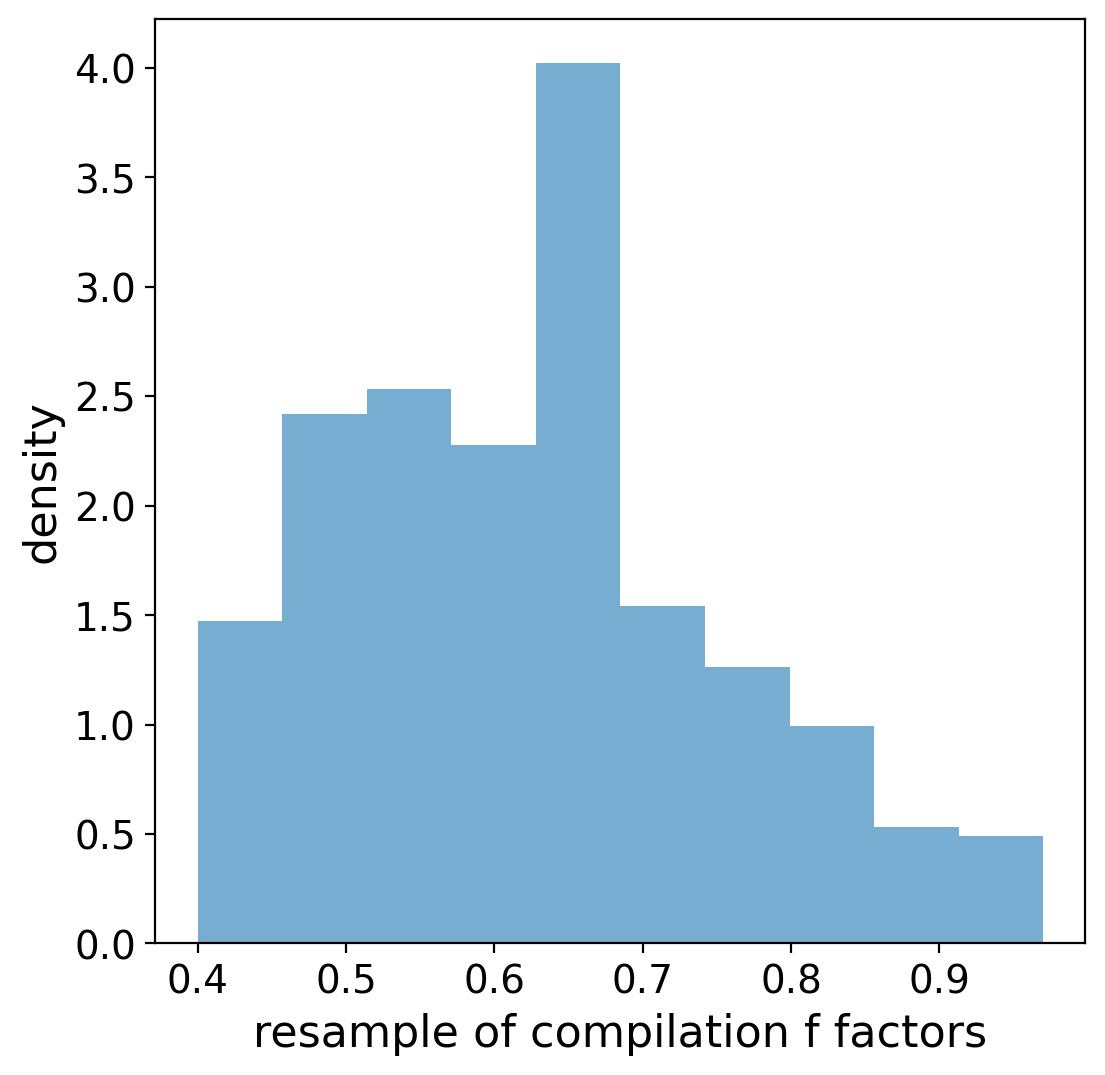

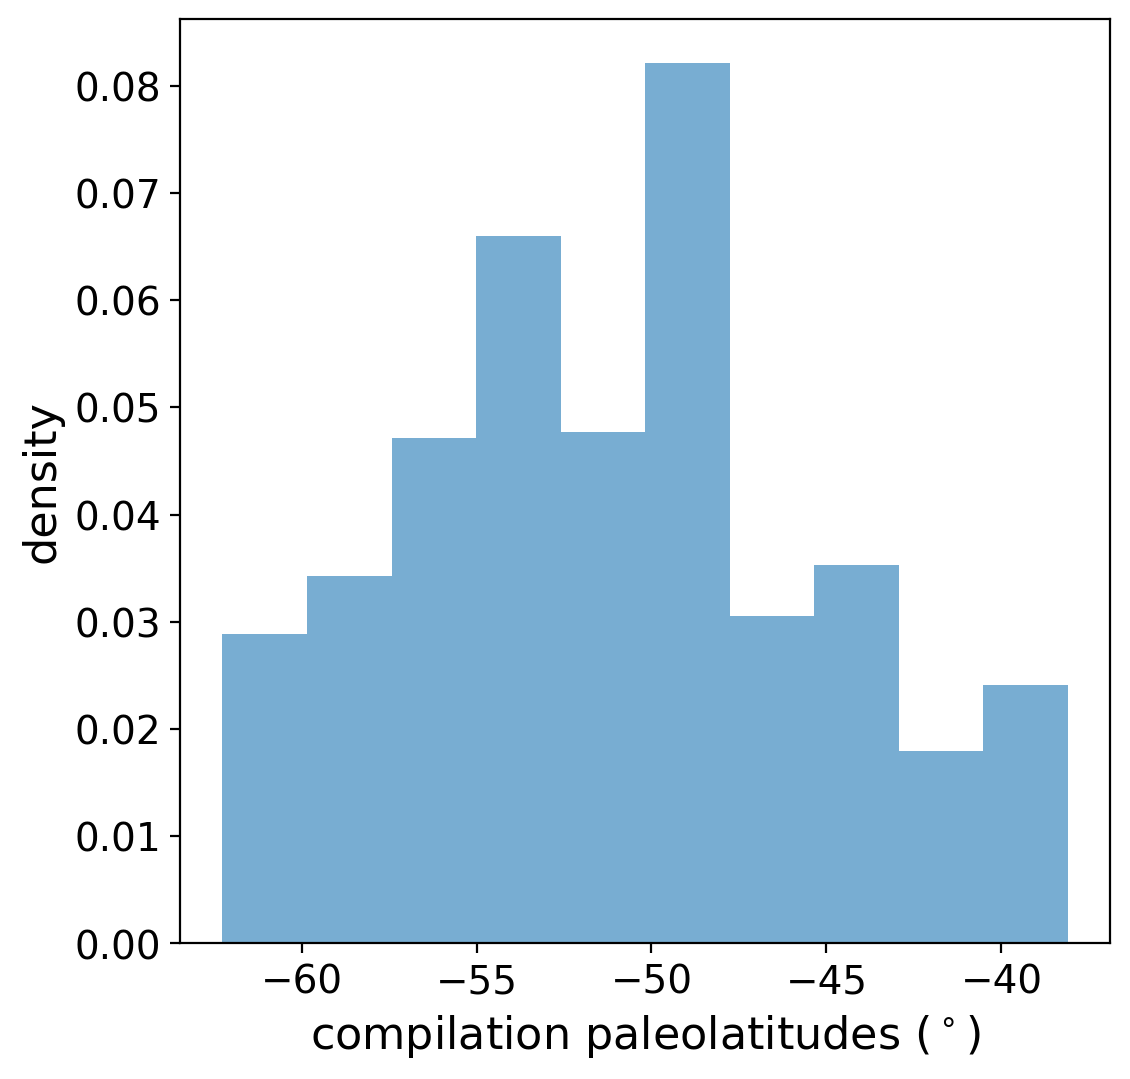

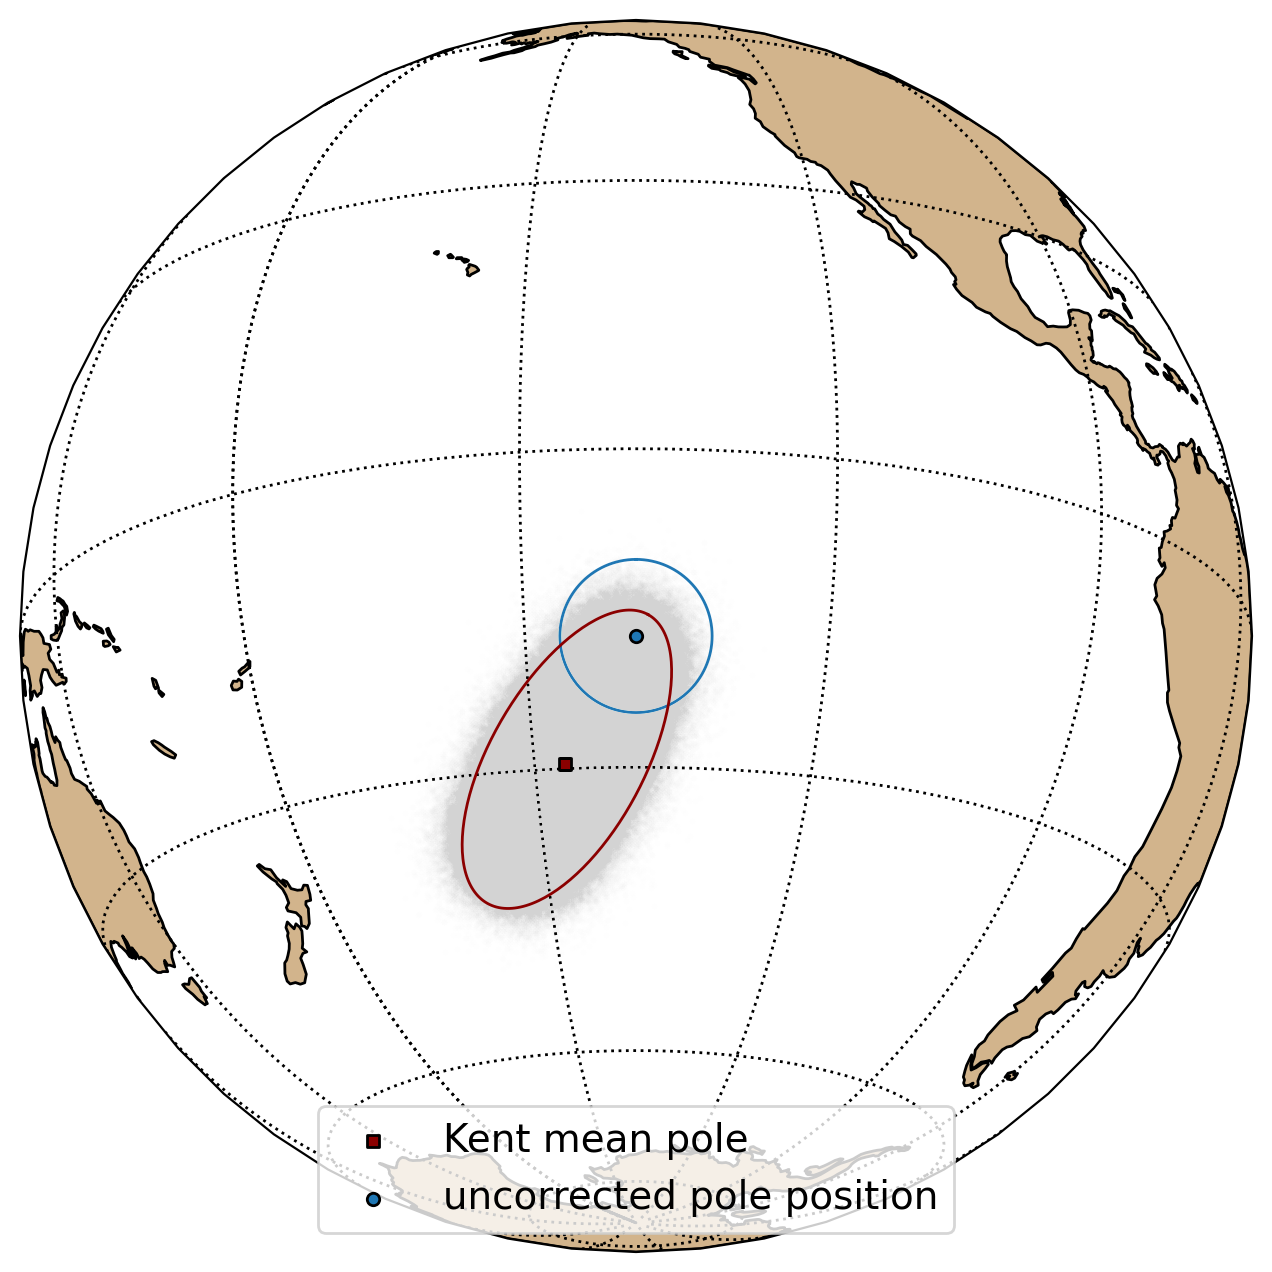

,Terrane,ROCKNAME,Lithology,SLAT,SLONG,nominal age,lomagage,himagage,Grade,f method,...,PLONG,Zdec,Zinc,Zeta,Edec,Einc,Eta,A95,n resampled,Comment
0,Laurentia-Scotland,Torridon Group,,57.9,354.3,975,950,1050,B,"compilation f (Pierce et al., 2022)",...,213.3,265.1,47.4,16.0,140.5,27.6,7.2,10.7,1000000,grand mean of seven published studies; no dire...


In [10]:
# Inclination-shallowing-corrected Kent mean pole (Pierce et al., 2022). The
# random seed is fixed so the exported summary is reproducible.
kent = pt.compilation_kent_pole(pole_mean, float(row['SLONG']), float(row['SLAT']), random_seed=1)
plt.show()

torridon_kent_summary = pt.make_kent_summary(
    summary, kent, 'compilation', 'this study',
    comment='grand mean of seven published studies; no directional distribution available for an E/I or SVEI determination of f')
pt.save_kent_summary(torridon_kent_summary, '975_Torridon')
torridon_kent_summary